In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [13]:
## loading the dataset
df = pd.read_csv("swiggy.csv")

In [14]:
## file check
print(df.shape)

(148541, 11)


In [15]:
print(df.head())

       id               name    city rating     rating_count   cost  \
0  567335     AB FOODS POINT  Abohar     --  Too Few Ratings  ₹ 200   
1  531342  Janta Sweet House  Abohar    4.4      50+ ratings  ₹ 200   
2  158203  theka coffee desi  Abohar    3.8     100+ ratings  ₹ 100   
3  187912          Singh Hut  Abohar    3.7      20+ ratings  ₹ 250   
4  543530      GRILL MASTERS  Abohar     --  Too Few Ratings  ₹ 250   

                      cuisine          lic_no  \
0            Beverages,Pizzas  22122652000138   
1               Sweets,Bakery  12117201000112   
2                   Beverages  22121652000190   
3            Fast Food,Indian  22119652000167   
4  Italian-American,Fast Food  12122201000053   

                                                link  \
0  https://www.swiggy.com/restaurants/ab-foods-po...   
1  https://www.swiggy.com/restaurants/janta-sweet...   
2  https://www.swiggy.com/restaurants/theka-coffe...   
3  https://www.swiggy.com/restaurants/singh-hut-n...  

In [16]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            148541 non-null  int64
 1   name          148455 non-null  str  
 2   city          148541 non-null  str  
 3   rating        148455 non-null  str  
 4   rating_count  148455 non-null  str  
 5   cost          148410 non-null  str  
 6   cuisine       148442 non-null  str  
 7   lic_no        148312 non-null  str  
 8   link          148541 non-null  str  
 9   address       148455 non-null  str  
 10  menu          148541 non-null  str  
dtypes: int64(1), str(10)
memory usage: 53.1 MB
None


In [17]:
# List headers with their data types
df.dtypes

id              int64
name              str
city              str
rating            str
rating_count      str
cost              str
cuisine           str
lic_no            str
link              str
address           str
menu              str
dtype: object

In [18]:
cols_to_drop = ["id", "lic_no", "link", "address", "menu"]

df = df.drop(columns=cols_to_drop)

In [19]:
print(df.columns)
print("New shape:", df.shape)

Index(['name', 'city', 'rating', 'rating_count', 'cost', 'cuisine'], dtype='str')
New shape: (148541, 6)


In [20]:
## removing Duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (148506, 6)


In [21]:
## checking missing values
print(df.isnull().sum())

name             61
city              0
rating           61
rating_count     61
cost            106
cuisine          74
dtype: int64


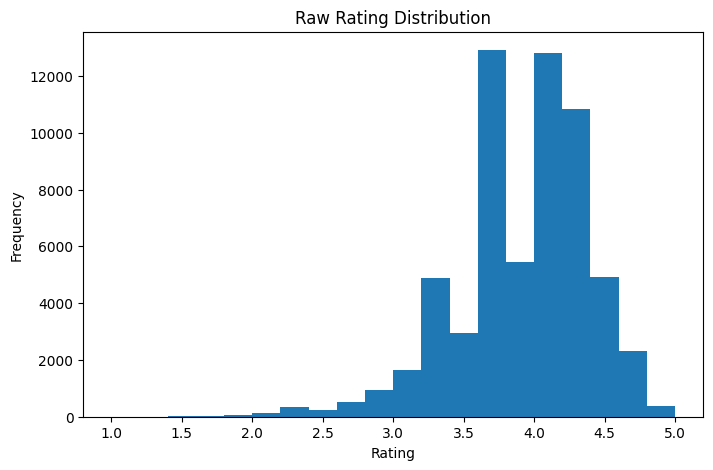

In [22]:
## Raw data Distribution
df_raw = df.copy()

plt.figure(figsize=(8,5))

plt.hist(
    pd.to_numeric(df_raw["rating"], errors="coerce"),
    bins=20
)

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Raw Rating Distribution")

plt.show()

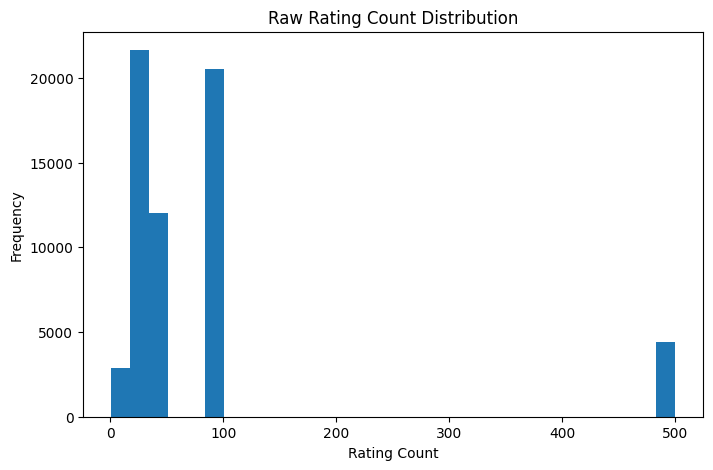

In [23]:
rating_count_raw = (
    df_raw["rating_count"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

plt.figure(figsize=(8,5))

plt.hist(
    pd.to_numeric(rating_count_raw, errors="coerce"),
    bins=30
)

plt.xlabel("Rating Count")
plt.ylabel("Frequency")
plt.title("Raw Rating Count Distribution")

plt.show()

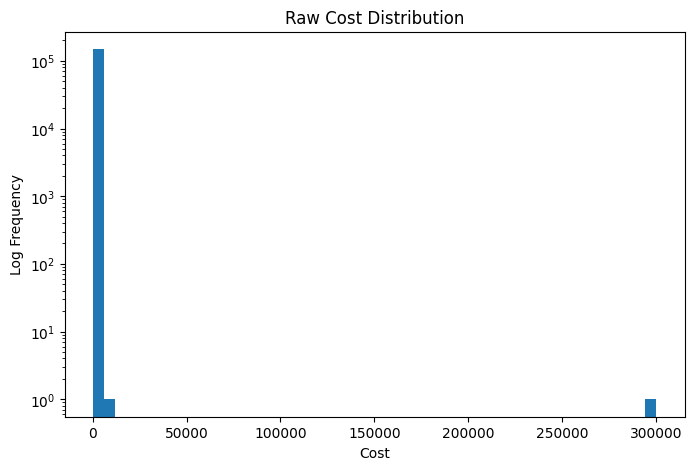

In [24]:
cost_raw = (
    df_raw["cost"]
    .astype(str)
    .str.replace(r"[₹,]", "", regex=True)
    .str.extract(r"(\d+)", expand=False)
)

plt.figure(figsize=(8,5))

plt.hist(
    pd.to_numeric(cost_raw, errors="coerce"),
    bins=50,
    log=True
)

plt.xlabel("Cost")
plt.ylabel("Log Frequency")
plt.title("Raw Cost Distribution")

plt.show()

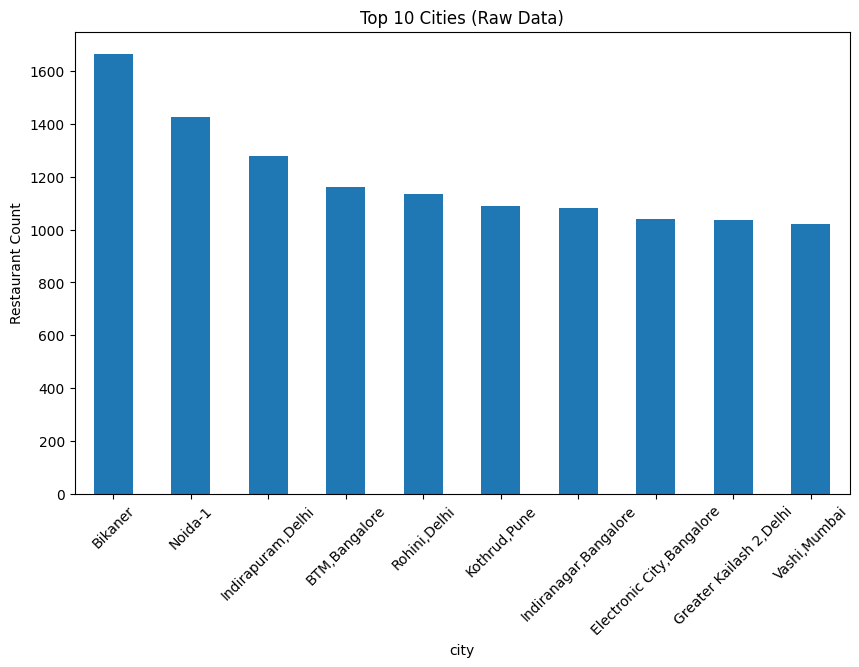

In [25]:
top_cities = df_raw["city"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_cities.plot(kind="bar")

plt.title("Top 10 Cities (Raw Data)")
plt.ylabel("Restaurant Count")
plt.xticks(rotation=45)

plt.show()

In [26]:
missing_pct = df_raw.isnull().mean() * 100
print(missing_pct.sort_values(ascending=False))

cost            0.071378
cuisine         0.049830
rating_count    0.041076
name            0.041076
rating          0.041076
city            0.000000
dtype: float64


In [27]:
## removing the currency from cost
df["cost"] = (
    df["cost"]
    .astype(str)
    .str.replace(r"[₹,]", "", regex=True)
    .str.extract(r"(\d+)", expand=False)
)

## converting cost to numerical value
df["cost"] = pd.to_numeric(df["cost"], errors="coerce")

print(df["cost"].dtype)
print(df["cost"].head(10))
print(df["cost"].isnull().sum())

float64
0    200.0
1    200.0
2    100.0
3    250.0
4    250.0
5    200.0
6    150.0
7    100.0
8    100.0
9    200.0
Name: cost, dtype: float64
106


In [28]:
## extracting the numerical values from rating count 
df["rating_count"] = (
    df["rating_count"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

## converting the datatype to numerical values 
df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

print(df["rating_count"].dtype)
print(df["rating_count"].head(10))
print(df["rating_count"].isnull().sum())

float64
0      NaN
1     50.0
2    100.0
3     20.0
4      NaN
5     20.0
6    100.0
7      NaN
8     20.0
9      NaN
Name: rating_count, dtype: float64
87068


In [29]:
## converting rating to numerical values
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

print(df["rating"].dtype)
print(df["rating"].head(10))
print(df["rating"].isnull().sum())

float64
0    NaN
1    4.4
2    3.8
3    3.7
4    NaN
5    3.6
6    4.0
7    NaN
8    4.2
9    NaN
Name: rating, dtype: float64
87068


In [30]:
## checking the impact of using median imputation and dropping for NULL values 
df_median = df.copy()

num_cols = ["rating", "rating_count", "cost"]

for col in num_cols:
    df_median[col] = pd.to_numeric(df_median[col], errors="coerce")
    df_median[col] = df_median[col].fillna(df_median[col].median())

df_median = df_median.dropna(subset=["city", "cuisine"])

In [31]:
df_drop = df.copy()
df_drop = df_drop.dropna()

In [32]:
print("Original rows:", df.shape[0])
print("After median imputation:", df_median.shape[0])
print("After dropping nulls:", df_drop.shape[0])

Original rows: 148506
After median imputation: 148432
After dropping nulls: 61418


In [33]:
lost_percentage = ((df.shape[0] - df_drop.shape[0]) / df.shape[0]) * 100
print(f"Data lost after dropping nulls: {lost_percentage:.2f}%")

Data lost after dropping nulls: 58.64%


In [34]:
print("Median-imputed rating stats:")
print(df_median["rating"].describe())

print("\nDropped-null rating stats:")
print(df_drop["rating"].describe())

Median-imputed rating stats:
count    148432.000000
mean          3.956319
std           0.300500
min           1.000000
25%           4.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Dropped-null rating stats:
count    61418.000000
mean         3.894536
std          0.460032
min          1.000000
25%          3.700000
50%          4.000000
75%          4.200000
max          5.000000
Name: rating, dtype: float64


In [35]:
print("Median-imputed rating mean:", df_median["rating"].mean())
print("Dropped-null rating mean:", df_drop["rating"].mean())

Median-imputed rating mean: 3.956319392044842
Dropped-null rating mean: 3.8945358038360087


In [36]:
before = df.shape[0]

df_cat_drop = df.dropna(subset=["city", "cuisine"])

after = df_cat_drop.shape[0]

loss_pct = (before - after) / before * 100

print("Rows before:", before)
print("Rows after categorical drop:", after)
print(f"Loss percentage: {loss_pct:.2f}%")

Rows before: 148506
Rows after categorical drop: 148432
Loss percentage: 0.05%


In [37]:
cols = ["rating", "rating_count", "cost"]

print("Before categorical drop:")
print(df[cols].describe())

print("\nAfter categorical drop:")
print(df_cat_drop[cols].describe())

Before categorical drop:
             rating  rating_count           cost
count  61438.000000  61438.000000  148400.000000
mean       3.894446     86.088886     287.603585
std        0.460063    120.211085     796.756557
min        1.000000      1.000000       1.000000
25%        3.700000     20.000000     200.000000
50%        4.000000     50.000000     250.000000
75%        4.200000    100.000000     300.000000
max        5.000000    500.000000  300350.000000

After categorical drop:
             rating  rating_count           cost
count  61434.000000  61434.000000  148388.000000
mean       3.894462     86.091399     287.608108
std        0.460054    120.214306     796.788431
min        1.000000      1.000000       1.000000
25%        3.700000     20.000000     200.000000
50%        4.000000     50.000000     250.000000
75%        4.200000    100.000000     300.000000
max        5.000000    500.000000  300350.000000


In [38]:
city_before = df["city"].value_counts(normalize=True)
city_after = df_cat_drop["city"].value_counts(normalize=True)

comparison = pd.concat(
    [city_before, city_after],
    axis=1,
    keys=["Before", "After"]
)

print(comparison.head(10))

                             Before     After
city                                         
Bikaner                    0.011218  0.011224
Noida-1                    0.009616  0.009614
Indirapuram,Delhi          0.008612  0.008617
BTM,Bangalore              0.007818  0.007822
Rohini,Delhi               0.007643  0.007640
Kothrud,Pune               0.007333  0.007337
Indiranagar,Bangalore      0.007272  0.007276
Electronic City,Bangalore  0.006996  0.007000
Greater Kailash 2,Delhi    0.006990  0.006986
Vashi,Mumbai               0.006882  0.006879


In [39]:
missing_cat = df[df[["city", "cuisine"]].isnull().any(axis=1)]
non_missing_cat = df.dropna(subset=["city", "cuisine"])

print("Mean rating (missing categorical):",
      missing_cat["rating"].mean())

print("Mean rating (non-missing categorical):",
      non_missing_cat["rating"].mean())

Mean rating (missing categorical): 3.6500000000000004
Mean rating (non-missing categorical): 3.8944623498388515


In [40]:
print("Shape of df:", df.shape)
print("Shape of df_cat_drop:", df_cat_drop.shape)

print("\nNull counts in df:")
print(df.isnull().sum())

print("\nNull counts in df_cat_drop:")
print(df_cat_drop.isnull().sum())

Shape of df: (148506, 6)
Shape of df_cat_drop: (148432, 6)

Null counts in df:
name               61
city                0
rating          87068
rating_count    87068
cost              106
cuisine            74
dtype: int64

Null counts in df_cat_drop:
name                0
city                0
rating          86998
rating_count    86998
cost               44
cuisine             0
dtype: int64


In [41]:
print(len(df["rating"]))
print(len(df["cost"]))
print(len(df_cat_drop["rating"]))
print(len(df_cat_drop["cost"]))

148506
148506
148432
148432


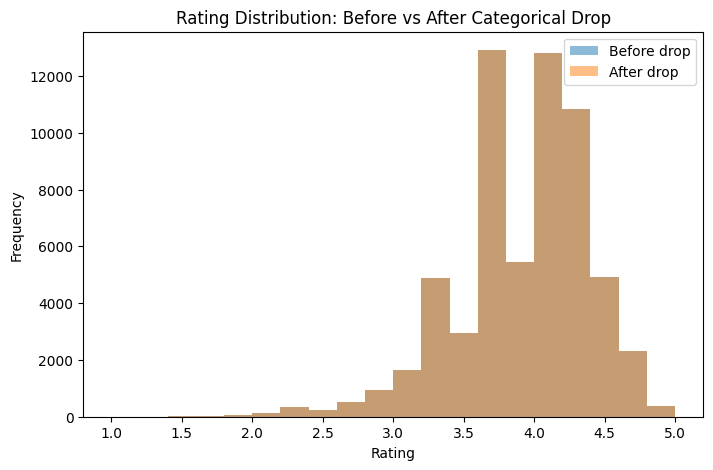

In [42]:
plt.figure(figsize=(8,5))

plt.hist(df["rating"], bins=20, alpha=0.5, label="Before drop")
plt.hist(df_cat_drop["rating"], bins=20, alpha=0.5, label="After drop")

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Rating Distribution: Before vs After Categorical Drop")
plt.legend()

plt.show()

In [43]:
print(df["rating"].dtype)
print(df_cat_drop["rating"].dtype)

print(df["rating"].isnull().sum())
print(df_cat_drop["rating"].isnull().sum())

print(df["rating"].head())

float64
float64
87068
86998
0    NaN
1    4.4
2    3.8
3    3.7
4    NaN
Name: rating, dtype: float64


In [44]:
print(df["rating"].head(20))
print(df["rating"].unique()[:20])
print(df["rating"].dtype)

0     NaN
1     4.4
2     3.8
3     3.7
4     NaN
5     3.6
6     4.0
7     NaN
8     4.2
9     NaN
10    NaN
11    4.2
12    NaN
13    NaN
14    4.4
15    NaN
16    4.0
17    NaN
18    NaN
19    4.7
Name: rating, dtype: float64
[nan 4.4 3.8 3.7 3.6 4.  4.2 4.7 4.1 3.5 3.1 3.4 3.3 4.8 3.9 2.7 4.3 2.9
 4.5 2.5]
float64


In [45]:
rating_clean = (
    df["rating"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)", expand=False)
)

rating_clean = pd.to_numeric(rating_clean, errors="coerce")

print("Non-null ratings:", rating_clean.notnull().sum())

Non-null ratings: 61438


In [46]:
print(rating_clean.head())
print(rating_clean.describe())

0    NaN
1    4.4
2    3.8
3    3.7
4    NaN
Name: rating, dtype: float64
count    61438.000000
mean         3.894446
std          0.460063
min          1.000000
25%          3.700000
50%          4.000000
75%          4.200000
max          5.000000
Name: rating, dtype: float64


C:\Users\Pratik\AppData\Local\Temp\ipykernel_9368\2261346757.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


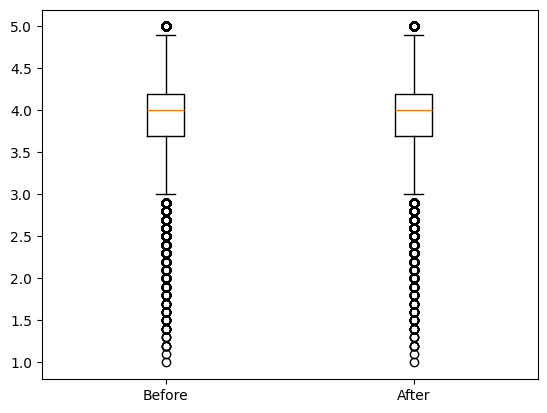

In [47]:
rating_after = (
    df_cat_drop["rating"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)", expand=False)
)

rating_after = pd.to_numeric(rating_after, errors="coerce")

plt.boxplot(
    [rating_clean.dropna(), rating_after.dropna()],
    labels=["Before", "After"]
)

plt.show()

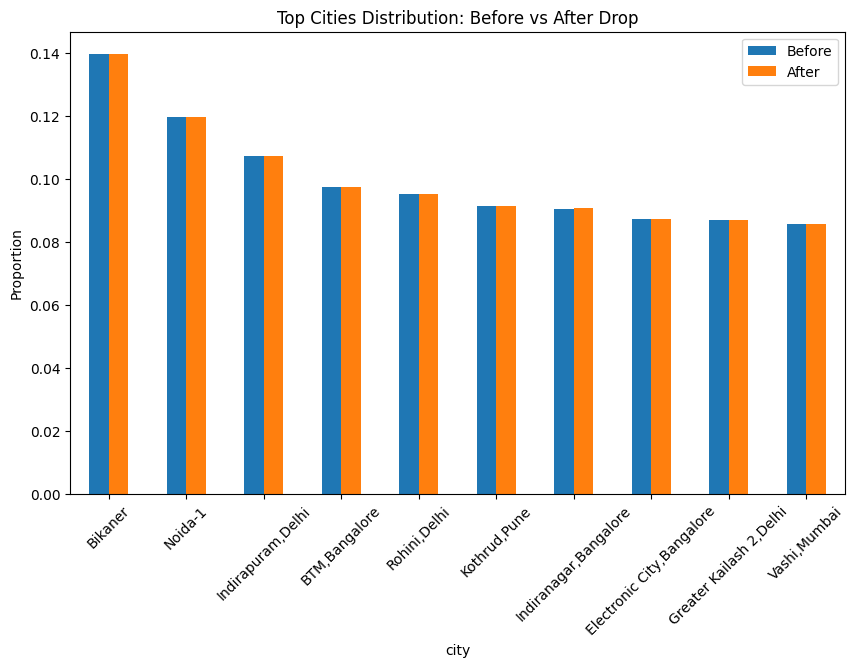

In [48]:
top_cities = df["city"].value_counts().head(10).index

before = df[df["city"].isin(top_cities)]["city"].value_counts(normalize=True)
after = df_cat_drop[df_cat_drop["city"].isin(top_cities)]["city"].value_counts(normalize=True)

comparison = pd.DataFrame({
    "Before": before,
    "After": after
})

comparison.plot(kind="bar", figsize=(10,6))

plt.title("Top Cities Distribution: Before vs After Drop")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

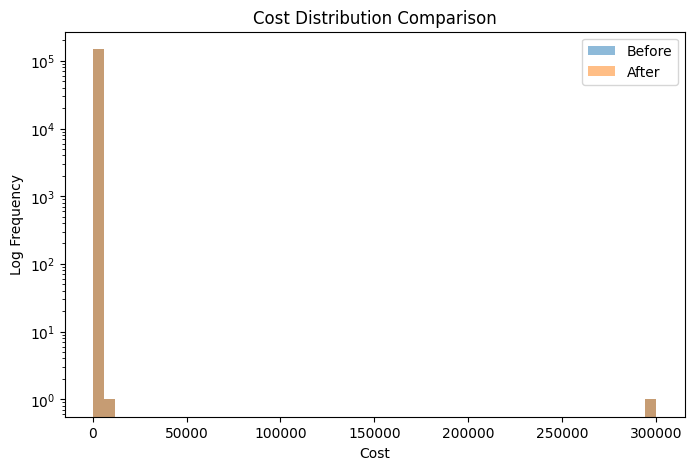

In [49]:
plt.figure(figsize=(8,5))

plt.hist(df["cost"], bins=50, alpha=0.5, label="Before", log=True)
plt.hist(df_cat_drop["cost"], bins=50, alpha=0.5, label="After", log=True)

plt.xlabel("Cost")
plt.ylabel("Log Frequency")
plt.title("Cost Distribution Comparison")
plt.legend()

plt.show()

In [50]:
## Handling Null values dropping null values in all the below mentioned columns as the data set is large and it has created hardware concerns

# Columns required for the recommender
required_cols = ["rating", "rating_count", "cost", "city", "cuisine"]

# Drop rows with nulls in required columns
df = df.dropna(subset=required_cols)

# Reset index for clean mapping later
df = df.reset_index(drop=True)

# Verification
print("Null values remaining:")
print(df[required_cols].isnull().sum())

print("\nFinal dataset shape:")
print(df.shape)

Null values remaining:
rating          0
rating_count    0
cost            0
city            0
cuisine         0
dtype: int64

Final dataset shape:
(61418, 6)


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61418 entries, 0 to 61417
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          61418 non-null  str    
 1   city          61418 non-null  str    
 2   rating        61418 non-null  float64
 3   rating_count  61418 non-null  float64
 4   cost          61418 non-null  float64
 5   cuisine       61418 non-null  str    
dtypes: float64(3), str(3)
memory usage: 5.6 MB


In [52]:
df.to_csv(r"E:\GuviDatascienceCourse\Project\Swiggy\cleaned_data.csv", index=False)
print("Cleaned data saved successfully!")

Cleaned data saved successfully!


#### ENCODING THE DATA SET


In [53]:
# Step: Select top 20 cities

top_20_cities = df["city"].value_counts().head(20).index

df_top = df[df["city"].isin(top_20_cities)].copy()

df_top.reset_index(drop=True, inplace=True)

print("Filtered dataset shape:", df_top.shape)
print(df_top["city"].value_counts())

Filtered dataset shape: (8495, 6)
city
Bikaner                                850
Indiranagar,Bangalore                  601
Noida-1                                545
Koramangala,Bangalore                  483
HSR,Bangalore                          445
BTM,Bangalore                          434
Greater Kailash 2,Delhi                414
Whitefield,Bangalore                   400
Electronic City,Bangalore              395
Bandra West,Mumbai                     392
Kammanahalli/Kalyan Nagar,Bangalore    376
Madhapur,Hyderabad                     372
Kukatpally,Hyderabad                   371
sohna road,Gurgaon                     369
Vashi,Mumbai                           355
Viman Nagar,Pune                       350
Patna                                  340
Powai,Mumbai                           336
Banjara Hills,Hyderabad                335
Arekere,Bangalore                      332
Name: count, dtype: int64


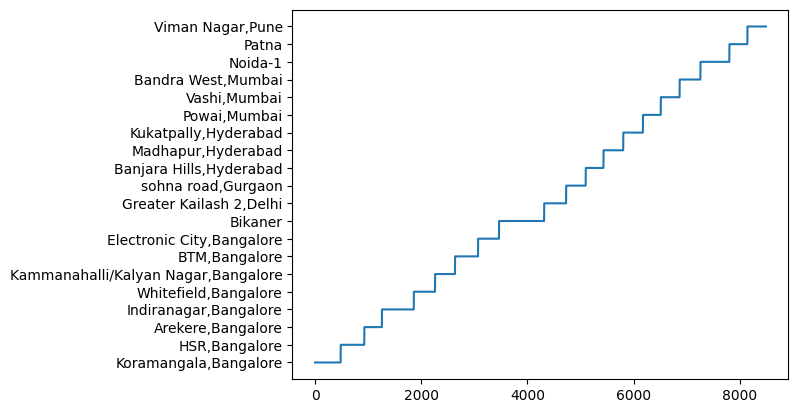

In [54]:
plt.plot(df_top["city"])
plt.show()

In [55]:
df_top.to_csv("model_data.csv", index=False)

In [56]:
clean_df = pd.read_csv("cleaned_data.csv")
print(df.shape)
print(df.columns)

(61418, 6)
Index(['name', 'city', 'rating', 'rating_count', 'cost', 'cuisine'], dtype='str')


In [57]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61418 entries, 0 to 61417
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          61418 non-null  str    
 1   city          61418 non-null  str    
 2   rating        61418 non-null  float64
 3   rating_count  61418 non-null  float64
 4   cost          61418 non-null  float64
 5   cuisine       61418 non-null  str    
dtypes: float64(3), str(3)
memory usage: 5.6 MB


In [58]:
clean_df.describe()

,rating,rating_count,cost
count,61418.000000,61418.000000,61418.000000
mean,3.894536,86.099661,297.647628
std,0.460032,120.227682,170.744410
min,1.000000,1.000000,1.000000
25%,3.700000,20.000000,200.000000
50%,4.000000,50.000000,250.000000
75%,4.200000,100.000000,350.000000
max,5.000000,500.000000,3000.000000


In [59]:
categorical_cols = ["city", "cuisine"]
numerical_cols = ["rating", "rating_count", "cost"]

In [60]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_cat = encoder.fit_transform(df_top[categorical_cols])

In [61]:
encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df_top.index
)

In [62]:
encoded_df = pd.concat(
    [df_top[numerical_cols], encoded_cat_df],
    axis=1
)

In [64]:
print(encoded_df.shape)

(8495, 873)


In [65]:
print(encoded_df.head())

   rating  rating_count   cost  city_Arekere,Bangalore  city_BTM,Bangalore  \
0     3.8          50.0  300.0                     0.0                 0.0   
1     3.5          20.0  200.0                     0.0                 0.0   
2     4.1         100.0  250.0                     0.0                 0.0   
3     3.4          20.0  350.0                     0.0                 0.0   
4     4.2         500.0  500.0                     0.0                 0.0   

   city_Bandra West,Mumbai  city_Banjara Hills,Hyderabad  city_Bikaner  \
0                      0.0                           0.0           0.0   
1                      0.0                           0.0           0.0   
2                      0.0                           0.0           0.0   
3                      0.0                           0.0           0.0   
4                      0.0                           0.0           0.0   

   city_Electronic City,Bangalore  city_Greater Kailash 2,Delhi  ...  \
0             

In [66]:
encoded_df.info()
encoded_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8495 entries, 0 to 8494
Columns: 873 entries, rating to cuisine_Waffle,Desserts
dtypes: float64(873)
memory usage: 56.6 MB


,rating,rating_count,cost,"city_Arekere,Bangalore","city_BTM,Bangalore","city_Bandra West,Mumbai","city_Banjara Hills,Hyderabad",city_Bikaner,"city_Electronic City,Bangalore","city_Greater Kailash 2,Delhi",...,"cuisine_Tibetan,Nepalese","cuisine_Tibetan,North Indian","cuisine_Tibetan,Snacks",cuisine_Turkish,"cuisine_Turkish,Arabian","cuisine_Turkish,Middle Eastern","cuisine_Vietnamese,Asian","cuisine_Waffle,Bakery","cuisine_Waffle,Beverages","cuisine_Waffle,Desserts"
count,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,...,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000,8495.000000
mean,3.964308,90.013891,344.829076,0.039082,0.051089,0.046145,0.039435,0.100059,0.046498,0.048735,...,0.000235,0.000235,0.000118,0.000235,0.000118,0.000235,0.000118,0.000471,0.000353,0.001295
std,0.473013,126.369166,213.361393,0.193801,0.220192,0.209811,0.194639,0.300096,0.210573,0.215325,...,0.015343,0.015343,0.010850,0.015343,0.010850,0.015343,0.010850,0.021696,0.018790,0.035963
min,1.200000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.800000,20.000000,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,50.000000,300.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.300000,100.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,500.000000,3000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [67]:
encoded_df.to_csv(
    r"E:\GuviDatascienceCourse\Project\Swiggy\encoded_data.csv",
    index=False
)

print("Encoded data saved successfully!")

Encoded data saved successfully!


In [68]:
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)


print("Encoded dataset shape:", encoded_df.shape)
print("Null values:", encoded_df.isnull().sum().sum())

Encoded dataset shape: (8495, 873)
Null values: 0


In [69]:
print(len(df), len(encoded_df))
print("Number of encoded features:", encoded_df.shape[1])

61418 8495
Number of encoded features: 873


In [70]:
print(encoded_df.dtypes.unique())
print(encoded_df.dtypes)

[dtype('float64')]
rating                            float64
rating_count                      float64
cost                              float64
city_Arekere,Bangalore            float64
city_BTM,Bangalore                float64
                                   ...   
cuisine_Turkish,Middle Eastern    float64
cuisine_Vietnamese,Asian          float64
cuisine_Waffle,Bakery             float64
cuisine_Waffle,Beverages          float64
cuisine_Waffle,Desserts           float64
Length: 873, dtype: object


In [71]:
encoded_df = pd.read_csv("encoded_data.csv")
clean_df = pd.read_csv("cleaned_data.csv")


print(len(encoded_df), len(clean_df))

8495 61418


In [72]:
encoded_df = encoded_df.drop(columns=["name", "city", "cuisine"], errors="ignore")

non_numeric_cols = encoded_df.select_dtypes(exclude=["number"]).columns
print(non_numeric_cols)

Index([], dtype='str')


In [73]:
print(encoded_df.select_dtypes(exclude=["number"]).columns)

Index([], dtype='str')


In [74]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(encoded_df)

print("Scaled shape:", encoded_df.shape)

Scaled shape: (8495, 873)


In [75]:
print(encoded_df.shape)

(8495, 873)


In [76]:
similarity_matrix = cosine_similarity(scaled_features)
print(similarity_matrix.shape)

(8495, 8495)


In [77]:
def recommend(index, n=5):

    base_city = df_top.iloc[index]["city"]

    similarity_scores = similarity_matrix[index]

    sorted_indices = np.argsort(similarity_scores)[::-1]

    filtered = [
        i for i in sorted_indices
        if df_top.iloc[i]["city"] == base_city and i != index
    ]

    return df_top.iloc[filtered[:n]][
        ["name", "city", "cuisine", "rating", "cost"]
    ]

In [78]:
recommend(25)

,name,city,cuisine,rating,cost
213,The Daily Meal,"Koramangala,Bangalore","North Indian,Punjabi",4.3,200.0
141,NH1 Bowls - Highway To North,"Koramangala,Bangalore","North Indian,Punjabi",4.5,250.0
261,Paratha Box by EatFit,"Koramangala,Bangalore","North Indian,Punjabi",3.9,250.0
58,Maa Di Hatti,"Koramangala,Bangalore","North Indian,Punjabi",3.8,150.0
329,Tapri By The Corner,"Koramangala,Bangalore","North Indian,Chinese",4.0,250.0


In [79]:
pca = PCA(n_components=50, random_state=42)

pca_features = pca.fit_transform(scaled_features)

print("PCA shape:", pca_features.shape)

PCA shape: (8495, 50)


In [80]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

tsne_features = tsne.fit_transform(pca_features)

sample_idx = np.random.choice(len(pca_features), 4000, replace=False)

tsne_features = tsne.fit_transform(pca_features[sample_idx])

# Convert city to numeric codes
city_codes = df_top["city"].astype("category").cat.codes

# If you sampled for t-SNE, match the same indices
city_codes_sample = city_codes.iloc[sample_idx]

city_codes_sample = city_codes.iloc[sample_idx]

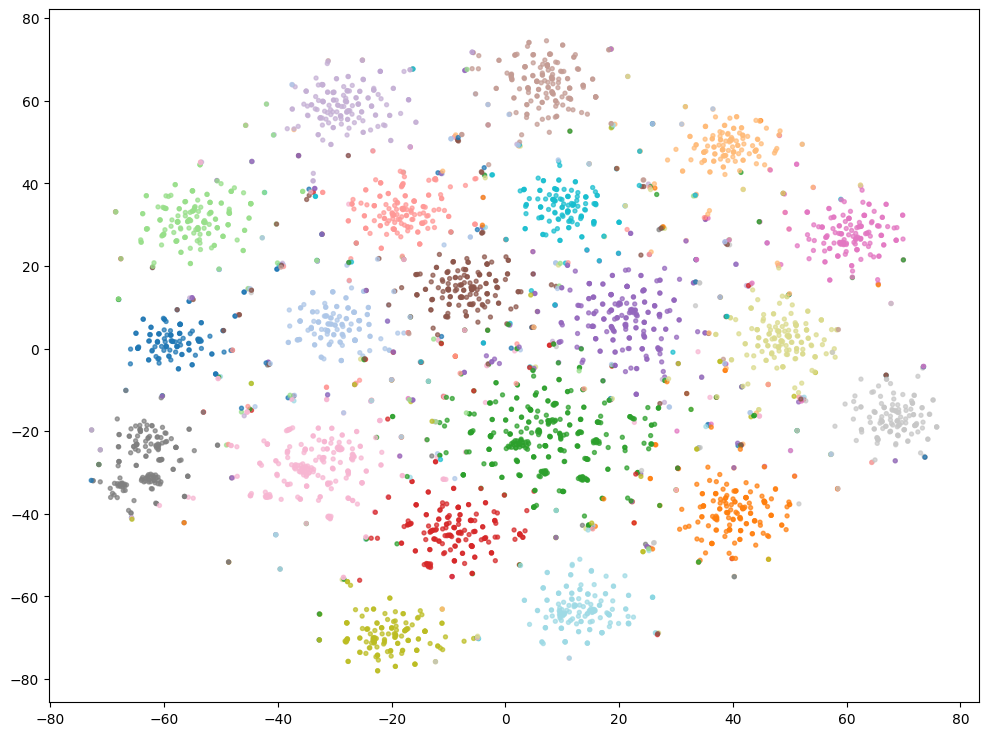

In [81]:
plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    tsne_features[:, 0],
    tsne_features[:, 1],
    c=city_codes_sample,
    cmap="tab20",
    s=8,
    alpha=0.7
)

In [82]:
# save similarity matrix
np.save("similarity_top20.npy", similarity_matrix)

In [83]:
## verification by passing manual input
manual_input = {
    "city": "BTM,Bangalore",
    "cuisine": "South Indian",
    "rating": 2.2,
    "rating_count": 150,
    "cost": 300
}

manual_df = pd.DataFrame([manual_input])

print("Manual Input:")
display(manual_df)

Manual Input:


,city,cuisine,rating,rating_count,cost
0,"BTM,Bangalore",South Indian,2.2,150,300


In [84]:
manual_cat = encoder.transform(manual_df[categorical_cols])

manual_cat_df = pd.DataFrame(
    manual_cat,
    columns=encoder.get_feature_names_out(categorical_cols)
)

In [85]:
manual_encoded = pd.concat(
    [manual_df[numerical_cols].reset_index(drop=True), manual_cat_df],
    axis=1
)

# Match training feature order
manual_encoded = manual_encoded.reindex(columns=encoded_df.columns, fill_value=0)

manual_scaled = scaler.transform(manual_encoded)
manual_similarity = cosine_similarity(manual_scaled, scaled_features)

In [86]:
# Step 1: rank by similarity
top_indices = np.argsort(manual_similarity[0])[::-1]

# Step 2: select ranked restaurants
recommendations = df.iloc[top_indices].copy()

# Step 3: apply hard filters
recommendations = recommendations[
    (recommendations["city"] == manual_input["city"]) &
    (recommendations["cuisine"] == manual_input["cuisine"]) &
    (recommendations["rating"] >= manual_input["rating"]) &
    (recommendations["cost"] <= manual_input["cost"])
]

# Step 4: take top 5 AFTER filtering
recommendations = recommendations.head(5)

print("\nTop Recommended Restaurants:\n")
print(recommendations)


Top Recommended Restaurants:

                              name           city  rating  rating_count  \
7305             SRI KRISHNA SAGAR  BTM,Bangalore     4.2          50.0   
7687             SLV MULBAGAL DOSA  BTM,Bangalore     3.0          20.0   
7609  five star new ambur biriyani  BTM,Bangalore     3.3         100.0   
7604                Hotel Aradhana  BTM,Bangalore     3.7          20.0   
7530             Madurai idly Shop  BTM,Bangalore     3.9         500.0   

       cost       cuisine  
7305  300.0  South Indian  
7687  200.0  South Indian  
7609  200.0  South Indian  
7604  250.0  South Indian  
7530  150.0  South Indian  


In [87]:
# similarity matrix for all restaurants
similarity_matrix = cosine_similarity(scaled_features)

# ignore self-similarity (diagonal = 1)
np.fill_diagonal(similarity_matrix, np.nan)

max_similarity = np.nanmax(similarity_matrix)
mean_similarity = np.nanmean(similarity_matrix)

print("Max similarity (between any two restaurants):", max_similarity)
print("Mean similarity (dataset-wide):", mean_similarity)

Max similarity (between any two restaurants): 1.0000000000000298
Mean similarity (dataset-wide): 0.0013931615719208425


In [88]:
top_similarities = []

for i in range(len(similarity_matrix)):
    row = similarity_matrix[i]
    row = row[~np.isnan(row)]
    top_similarities.append(np.max(row))

print("Average best match per restaurant:", np.mean(top_similarities))

Average best match per restaurant: 0.9496459267277775
